In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Load clean file ────────────────────────────────
df = pd.read_csv('retail_clean_final.csv', low_memory=False)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (1041663, 15)
Columns: ['InvoiceDate', 'Description', 'Description_Encoded', 'Quantity', 'Price', 'Revenue', 'Country_Grouped', 'Country_Encoded', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Quarter', 'WeekOfYear']


,InvoiceDate,Description,Description_Encoded,Quantity,Price,Revenue,Country_Grouped,Country_Encoded,Year,Month,Day,DayOfWeek,IsWeekend,Quarter,WeekOfYear
0,2009-12-01 07:45:00,15CM CHRISTMAS GLASS BALL 20 LIGHTS,24,12,6.95,83.4,United Kingdom,20,2009,12,1,1,0,4,49
1,2009-12-01 07:45:00,PINK CHERRY LIGHTS,2905,12,6.75,81.0,United Kingdom,20,2009,12,1,1,0,4,49
2,2009-12-01 07:45:00,WHITE CHERRY LIGHTS,4481,12,6.75,81.0,United Kingdom,20,2009,12,1,1,0,4,49
3,2009-12-01 07:45:00,"RECORD FRAME 7"" SINGLE SIZE",3211,48,2.10,100.8,United Kingdom,20,2009,12,1,1,0,4,49
4,2009-12-01 07:45:00,STRAWBERRY CERAMIC TRINKET BOX,4102,24,1.25,30.0,United Kingdom,20,2009,12,1,1,0,4,49


In [2]:
# Keep only normal retail quantities
# 86.9% of your data is already ≤ 12
# Removing bulk orders makes problem much simpler!

df_retail = df[df['Quantity'] <= 100].copy()
df_retail = df_retail.sort_values('InvoiceDate').reset_index(drop=True)

print(f"Original rows : {len(df):,}")
print(f"Retail rows   : {len(df_retail):,}")
print(f"Removed rows  : {len(df) - len(df_retail):,}")
print(f"\nNew Quantity distribution:")
print(df_retail['Quantity'].describe())

Original rows : 1,041,663
Retail rows   : 1,031,376
Removed rows  : 10,287

New Quantity distribution:
count    1.031376e+06
mean     7.887458e+00
std      1.245320e+01
min      1.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      1.000000e+02
Name: Quantity, dtype: float64


In [3]:
# Features and target on clean retail data
X = df_retail[['Description_Encoded', 'Country_Encoded',
               'Year', 'Month', 'Day', 'DayOfWeek',
               'IsWeekend', 'Quarter', 'WeekOfYear', 'Price']]

y = df_retail['Quantity']

# Time based split
split_index = int(len(df_retail) * 0.85)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows : {len(X_test):,}")

Train rows: 876,669
Test rows : 154,707


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,          # reduced depth
    min_samples_leaf=10,  # increased minimum samples
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("✅ Model trained!")

# Evaluate
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

print("\n===== RESULTS AFTER FILTERING =====")
print(f"Train R²  : {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²  : {r2_score(y_test, y_pred_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test  MAE : {mean_absolute_error(y_test, y_pred_test):.4f}")

gap = r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)
print(f"\nOverfitting gap: {gap:.4f}")
if gap > 0.1:
    print("⚠️  Overfitting detected!")
else:
    print("✅ No overfitting!")

✅ Model trained!

===== RESULTS AFTER FILTERING =====
Train R²  : 0.3192
Test  R²  : 0.2861
Train RMSE: 10.3522
Test  RMSE: 10.0583
Test  MAE : 5.6401

Overfitting gap: 0.0331
✅ No overfitting!


In [5]:
# Add predictions to test dataframe
test_df = df_retail.iloc[split_index:].copy()
test_df['Predicted_Quantity'] = y_pred_test
test_df['Predicted_Revenue']  = test_df['Predicted_Quantity'] * test_df['Price']
test_df['Actual_Revenue']     = test_df['Quantity'] * test_df['Price']

# Group by day
daily = test_df.groupby(
    test_df['InvoiceDate'].dt.date
).agg(
    Actual_Revenue    = ('Actual_Revenue', 'sum'),
    Predicted_Revenue = ('Predicted_Revenue', 'sum')
).reset_index()

# Revenue R²
revenue_r2 = r2_score(
    daily['Actual_Revenue'],
    daily['Predicted_Revenue']
)

print(f"===== REVENUE PREDICTION RESULTS =====")
print(f"Revenue R²: {revenue_r2:.4f}")
print(f"\nSample daily comparison:")
print(daily.head(10).to_string())

===== REVENUE PREDICTION RESULTS =====
Revenue R²: 0.8467

Sample daily comparison:
  InvoiceDate  Actual_Revenue  Predicted_Revenue
0  2011-10-07        35715.82       35161.735829
1  2011-10-09        11496.24       15734.437127
2  2011-10-10        43177.42       49959.716786
3  2011-10-11        42016.54       40046.533262
4  2011-10-12        31802.16       33255.750305
5  2011-10-13        34836.94       40949.407208
6  2011-10-14        34944.20       32267.689107
7  2011-10-16        21357.20       18315.419381
8  2011-10-17        43757.48       47740.549020
9  2011-10-18        42013.35       45352.342467


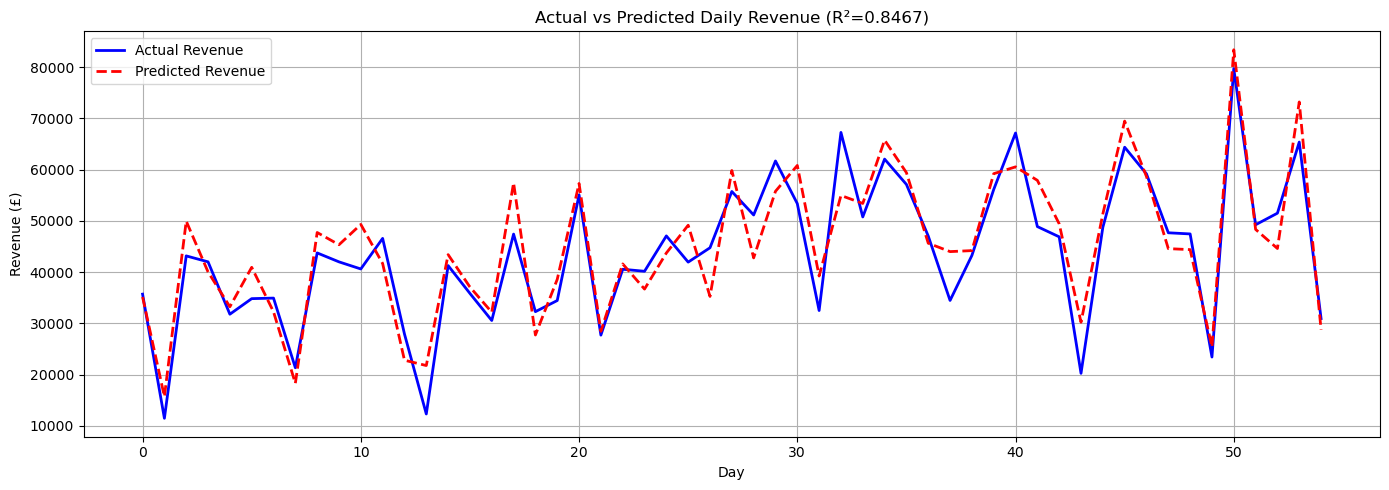

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily['Actual_Revenue'].values,
         label='Actual Revenue',
         color='blue', linewidth=2)
plt.plot(daily['Predicted_Revenue'].values,
         label='Predicted Revenue',
         color='red', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Daily Revenue (R²=0.8467)')
plt.xlabel('Day')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint

# Use only 20% sample for tuning — much faster!
sample_size = int(len(X_train) * 0.20)
X_tune = X_train.iloc[:sample_size]
y_tune = y_train.iloc[:sample_size]

print(f"Tuning on {len(X_tune):,} rows instead of {len(X_train):,}")

# Smaller search space
param_dist = {
    'n_estimators'     : randint(50, 200),
    'max_depth'        : randint(5, 15),
    'min_samples_leaf' : randint(5, 20),
}

# Faster settings
search = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 10,    # only 10 combinations
    cv                  = 3,     # only 3 folds
    scoring             = 'r2',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

search.fit(X_tune, y_tune)

print(f"\n✅ Tuning done!")
print(f"Best parameters: {search.best_params_}")
print(f"Best CV R²     : {search.best_score_:.4f}")

Tuning on 175,333 rows instead of 876,669
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Tuning done!
Best parameters: {'max_depth': 12, 'min_samples_leaf': 9, 'n_estimators': 149}
Best CV R²     : 0.3230


In [8]:
# Train best model on FULL training data with tuned parameters
best_rf = RandomForestRegressor(
    n_estimators    = 149,
    max_depth       = 12,
    min_samples_leaf= 9,
    random_state    = 42,
    n_jobs          = -1
)

best_rf.fit(X_train, y_train)
print("✅ Best model trained on full data!")

# Predict
y_pred_train_best = best_rf.predict(X_train)
y_pred_test_best  = best_rf.predict(X_test)

# Evaluate
print("\n===== TUNED MODEL RESULTS =====")
print(f"Train R²  : {r2_score(y_train, y_pred_train_best):.4f}")
print(f"Test  R²  : {r2_score(y_test, y_pred_test_best):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_best)):.4f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_best)):.4f}")
print(f"Test  MAE : {mean_absolute_error(y_test, y_pred_test_best):.4f}")

gap = r2_score(y_train, y_pred_train_best) - r2_score(y_test, y_pred_test_best)
print(f"\nOverfitting gap: {gap:.4f}")
if gap > 0.1:
    print("⚠️  Overfitting detected!")
else:
    print("✅ No overfitting!")

# Compare with previous
print(f"\n===== COMPARISON =====")
print(f"{'Metric':<15} {'Before':>10} {'After':>10}")
print("-" * 35)
print(f"{'Test R²':<15} {0.2861:>10.4f} {r2_score(y_test, y_pred_test_best):>10.4f}")
print(f"{'Test RMSE':<15} {10.0583:>10.4f} {np.sqrt(mean_squared_error(y_test, y_pred_test_best)):>10.4f}")
print(f"{'Test MAE':<15} {5.6401:>10.4f} {mean_absolute_error(y_test, y_pred_test_best):>10.4f}")

✅ Best model trained on full data!

===== TUNED MODEL RESULTS =====
Train R²  : 0.4994
Test  R²  : 0.3827
Train RMSE: 8.8769
Test  RMSE: 9.3528
Test  MAE : 5.2754

Overfitting gap: 0.1167
⚠️  Overfitting detected!

===== COMPARISON =====
Metric              Before      After
-----------------------------------
Test R²             0.2861     0.3827
Test RMSE          10.0583     9.3528
Test MAE            5.6401     5.2754


In [9]:
# Revenue comparison
test_df['Predicted_Quantity_Tuned'] = y_pred_test_best
test_df['Predicted_Revenue_Tuned']  = test_df['Predicted_Quantity_Tuned'] * test_df['Price']

daily_tuned = test_df.groupby(
    test_df['InvoiceDate'].dt.date
).agg(
    Actual_Revenue          = ('Actual_Revenue', 'sum'),
    Predicted_Revenue_Before= ('Predicted_Revenue', 'sum'),
    Predicted_Revenue_Tuned = ('Predicted_Revenue_Tuned', 'sum')
).reset_index()

revenue_r2_tuned = r2_score(
    daily_tuned['Actual_Revenue'],
    daily_tuned['Predicted_Revenue_Tuned']
)

print(f"===== REVENUE RESULTS =====")
print(f"Before tuning R²: 0.8467")
print(f"After tuning  R²: {revenue_r2_tuned:.4f}")
print(f"Improvement     : {revenue_r2_tuned - 0.8467:+.4f}")
print(f"\nSample comparison:")
print(daily_tuned.head(10).to_string())

===== REVENUE RESULTS =====
Before tuning R²: 0.8467
After tuning  R²: 0.9120
Improvement     : +0.0653

Sample comparison:
  InvoiceDate  Actual_Revenue  Predicted_Revenue_Before  Predicted_Revenue_Tuned
0  2011-10-07        35715.82              35161.735829             36223.712168
1  2011-10-09        11496.24              15734.437127             14510.919887
2  2011-10-10        43177.42              49959.716786             49105.890407
3  2011-10-11        42016.54              40046.533262             39944.351820
4  2011-10-12        31802.16              33255.750305             33353.715642
5  2011-10-13        34836.94              40949.407208             40063.759527
6  2011-10-14        34944.20              32267.689107             33149.840670
7  2011-10-16        21357.20              18315.419381             18437.968487
8  2011-10-17        43757.48              47740.549020             46437.738966
9  2011-10-18        42013.35              45352.342467           